# 07 — EDA Report: Integración y Automatización
**Consolidar el EDA en un reporte reproducible y comunicable.**

Este notebook tiene dos partes:
1. **EDA manual consolidado** — función `full_eda()` que aplica todo lo aprendido en los notebooks anteriores en una sola pasada
2. **EDA automatizado** — `ydata-profiling` (ex pandas-profiling) genera reportes HTML interactivos

## Cuándo usar cada uno

| | EDA manual | ydata-profiling |
|---|---|---|
| Control | Total | Limitado |
| Velocidad | Lento | Inmediato |
| Gráficas custom | Sí | No |
| Análisis específico del dominio | Sí | No |
| Primer contacto rápido | No ideal | Perfecto |
| Reporte para stakeholders | Custom | HTML listo |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

# Dataset completo con todos los problemas típicos
rng = np.random.default_rng(42)
n   = 5000

categories = rng.choice(['Electronics','Clothing','Home','Sports','Books','Beauty'], n, p=[0.25,0.22,0.18,0.15,0.12,0.08])
countries  = rng.choice(['US','UK','DE','MX','BR','FR','CA'], n, p=[0.35,0.15,0.12,0.10,0.10,0.10,0.08])
channels   = rng.choice(['organic','paid','email','direct','affiliate'], n, p=[0.30,0.25,0.20,0.15,0.10])
devices    = rng.choice(['mobile','desktop','tablet'], n, p=[0.55,0.35,0.10])
dates      = pd.date_range('2023-01-01', periods=n, freq='2h')
price      = np.where(categories=='Electronics', rng.lognormal(4.5,0.8,n),
             np.where(categories=='Clothing',    rng.lognormal(3.5,0.6,n),
                                                 rng.lognormal(3.2,0.7,n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = np.where(rng.uniform(0,1,n)<0.3, rng.uniform(0.05,0.40,n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)
rating     = rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.40,0.25]).astype(float)

# Inyectar problemas
miss_idx = rng.choice(n, size=int(n*0.08), replace=False)
rating[miss_idx[:250]] = np.nan
discount_arr = discount.astype(object); discount_arr[miss_idx[250:]] = np.nan
revenue[rng.choice(n, 20, replace=False)] = rng.uniform(5000, 15000, 20)

df = pd.DataFrame({
    'order_id':  np.arange(100_000, 100_000 + n),
    'date':      dates,
    'category':  categories, 'country': countries,
    'channel':   channels,   'device':  devices,
    'price':     price,      'quantity': qty,
    'discount':  discount_arr,'revenue': revenue, 'rating': rating,
})

print(f'Dataset: {df.shape}')

Dataset: (5000, 11)


## 1 — Función `full_eda()`: EDA completo en una pasada

═════════════════════════════════════════════════════════════════
EDA REPORT — 5,000 filas × 11 columnas
═════════════════════════════════════════════════════════════════
  Numéricas:  4 columnas: ['order_id', 'price', 'quantity', 'rating']
  Categóric.: 4 columnas: ['category', 'country', 'channel', 'device']
  Datetime:   1 columnas: ['date']
  Duplicados: 0 (0.00%)
  Missing:    {'discount': '3.0%', 'rating': '5.0%'}
  Outliers:   {'price': 444, 'rating': 230}


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_16727/414970735.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes('object').columns if df[c].nunique() <= max_cat_unique]


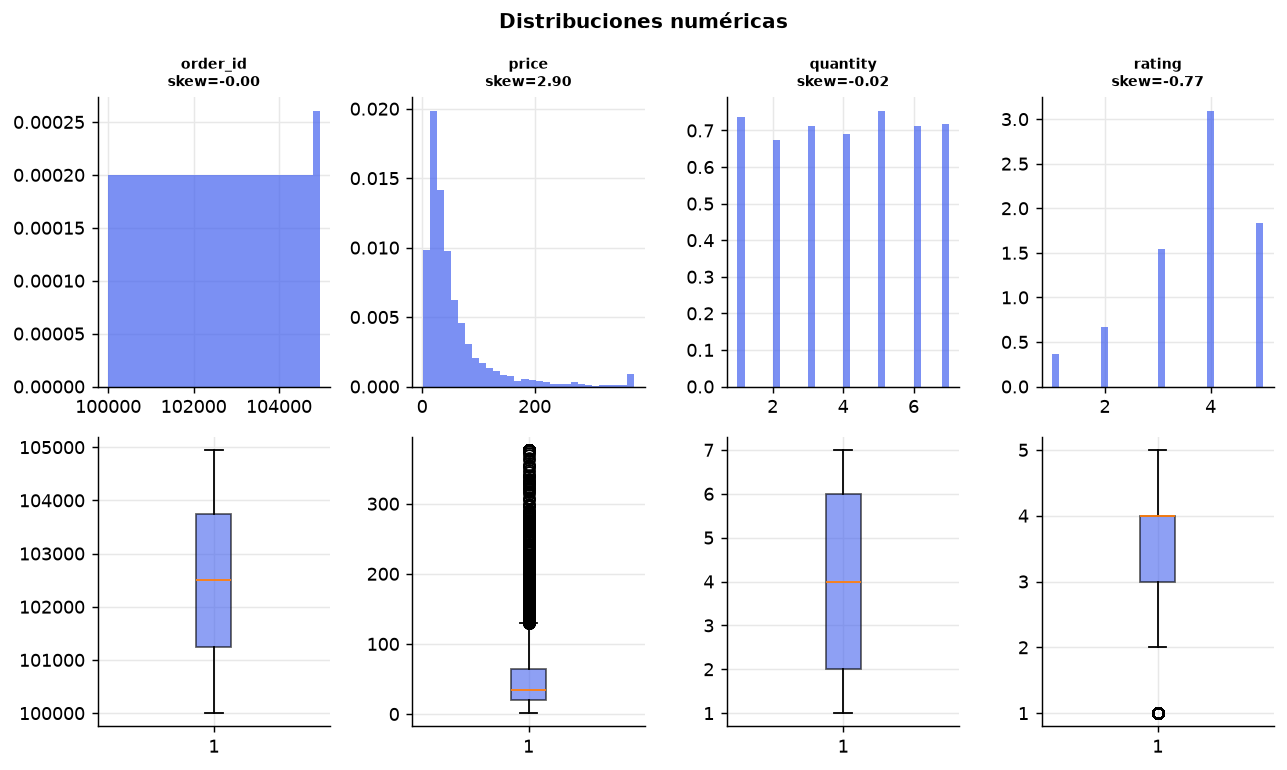

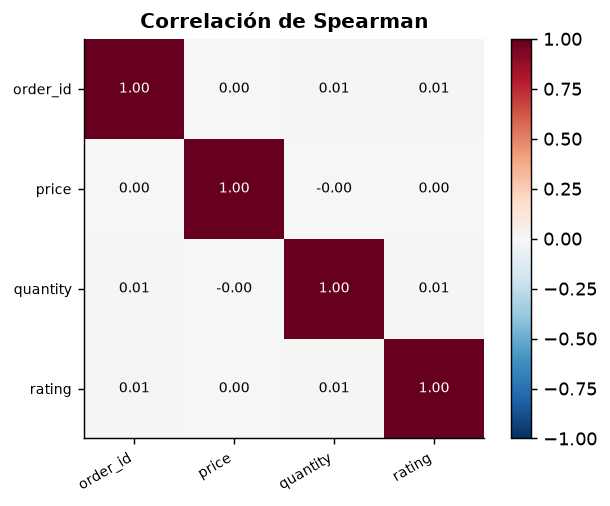

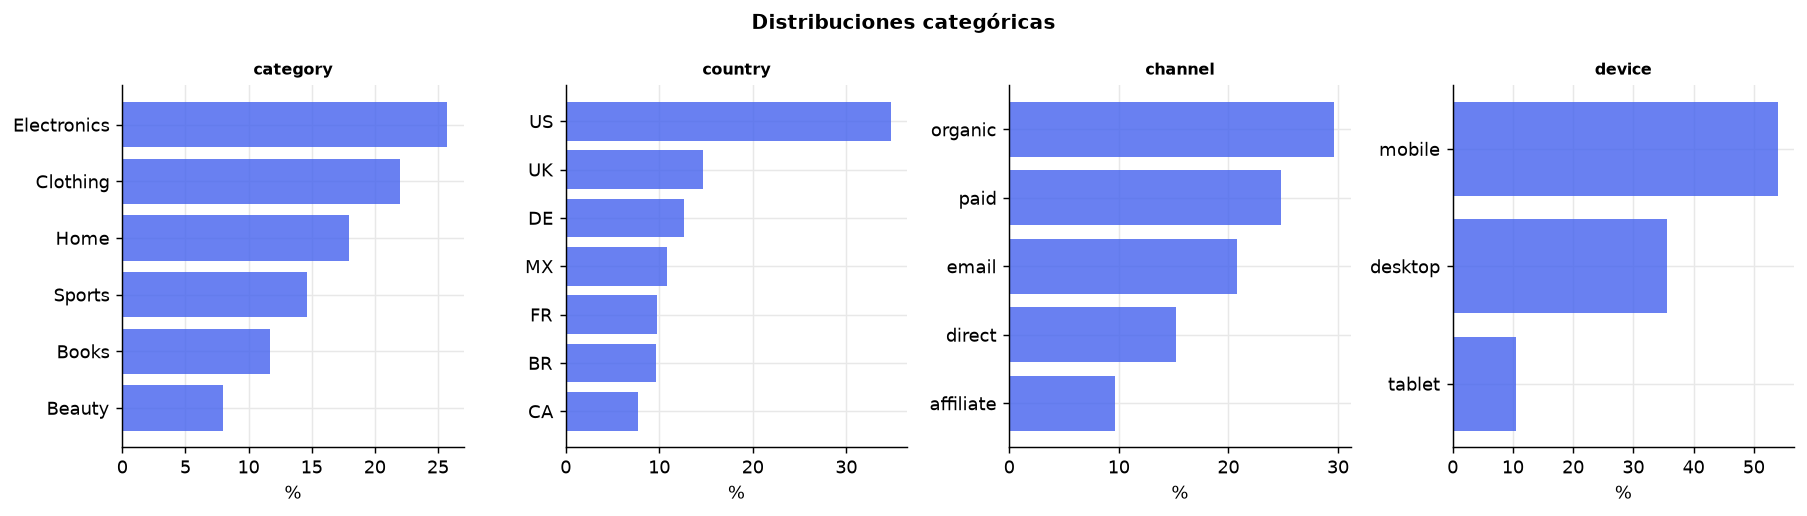


  Target (revenue):
    mean=250.59  median=114.96  std=697.65  skew=12.99

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═


In [2]:
def full_eda(df: pd.DataFrame, target: str | None = None, max_cat_unique: int = 20) -> dict:
    """
    Corre EDA completo sobre un DataFrame y devuelve un dict de hallazgos.
    Imprime resumen y genera gráficas.

    Args:
        df:             DataFrame a analizar
        target:         Columna objetivo (si existe) — se analiza vs. el resto
        max_cat_unique: Columnas con más valores únicos se ignoran en análisis cat
    """
    findings = {}

    # ── 1. Estructura básica ─────────────────────────────────────────────
    num_cols = df.select_dtypes('number').columns.tolist()
    cat_cols = [c for c in df.select_dtypes('object').columns if df[c].nunique() <= max_cat_unique]
    dt_cols  = df.select_dtypes('datetime').columns.tolist()
    if target and target in num_cols: num_cols.remove(target)
    if target and target in cat_cols: cat_cols.remove(target)

    miss  = df.isnull().mean()
    n_dup = df.duplicated().sum()

    findings['shape']      = df.shape
    findings['duplicates'] = int(n_dup)
    findings['missing']    = miss[miss > 0].to_dict()

    print('═' * 65)
    print(f'EDA REPORT — {df.shape[0]:,} filas × {df.shape[1]} columnas')
    print('═' * 65)
    print(f'  Numéricas:  {len(num_cols)} columnas: {num_cols}')
    print(f'  Categóric.: {len(cat_cols)} columnas: {cat_cols}')
    print(f'  Datetime:   {len(dt_cols)} columnas: {dt_cols}')
    print(f'  Duplicados: {n_dup} ({n_dup/len(df):.2%})')
    print(f'  Missing:    {dict((k, f"{v:.1%}") for k, v in findings["missing"].items())}' if findings['missing'] else '  Missing:    ninguno')

    # ── 2. Outliers rápidos (IQR) ────────────────────────────────────────
    outlier_counts = {}
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr    = q3 - q1
        n_out  = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
        if n_out > 0:
            outlier_counts[col] = int(n_out)
    findings['outliers_iqr'] = outlier_counts
    print(f'  Outliers:   {outlier_counts}')

    # ── 3. Distribuciones numéricas ──────────────────────────────────────
    cols_to_plot = num_cols[:6]  # máximo 6
    if cols_to_plot:
        fig, axes = plt.subplots(2, len(cols_to_plot), figsize=(min(14, len(cols_to_plot)*2.5), 6))
        if len(cols_to_plot) == 1: axes = axes.reshape(2, 1)
        for j, col in enumerate(cols_to_plot):
            data = df[col].dropna().clip(upper=df[col].quantile(0.99))
            axes[0,j].hist(data, bins=30, color='#4361ee', alpha=0.7, density=True)
            axes[0,j].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=8)
            axes[1,j].boxplot(data, patch_artist=True,
                              boxprops=dict(facecolor='#4361ee', alpha=0.6))
            axes[1,j].set_title('', fontsize=8)
        plt.suptitle('Distribuciones numéricas', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── 4. Correlaciones ────────────────────────────────────────────────
    if len(num_cols) >= 2:
        corr = df[num_cols].corr(method='spearman')
        fig, ax = plt.subplots(figsize=(max(5, len(num_cols)), max(4, len(num_cols)-1)))
        im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
        ax.set_xticklabels(num_cols, rotation=30, ha='right', fontsize=8)
        ax.set_yticklabels(num_cols, fontsize=8)
        ax.set_title('Correlación de Spearman')
        ax.grid(False)
        for i in range(len(num_cols)):
            for j in range(len(num_cols)):
                ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()

        # Correlaciones altas
        high_corr = [(num_cols[i], num_cols[j], corr.iloc[i,j])
                     for i in range(len(num_cols)) for j in range(i+1, len(num_cols))
                     if abs(corr.iloc[i,j]) > 0.5]
        findings['high_correlations'] = high_corr
        if high_corr:
            print(f'\n  Correlaciones altas (|ρ|>0.5):')
            for c1, c2, r in high_corr:
                print(f'    {c1} vs {c2}: ρ={r:.3f}')

    # ── 5. Categóricas ──────────────────────────────────────────────────
    if cat_cols:
        fig, axes = plt.subplots(1, min(len(cat_cols), 4), figsize=(min(14, len(cat_cols)*3.5), 4))
        if len(cat_cols) == 1: axes = [axes]
        for ax, col in zip(axes, cat_cols[:4]):
            vc = df[col].value_counts(normalize=True).head(8)
            ax.barh(vc.index[::-1], vc.values[::-1] * 100, color='#4361ee', alpha=0.8)
            ax.set_title(col, fontsize=9)
            ax.set_xlabel('%')
        plt.suptitle('Distribuciones categóricas', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── 6. Target analysis ──────────────────────────────────────────────
    if target and target in df.columns:
        print(f'\n  Target ({target}):')
        t = df[target].dropna()
        print(f'    mean={t.mean():.2f}  median={t.median():.2f}  std={t.std():.2f}  skew={t.skew():.2f}')

    print('\n═' * 65)
    return findings


findings = full_eda(df, target='revenue')

## 2 — ydata-profiling: reporte HTML automático

In [3]:
try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(
        df,
        title='E-Commerce EDA Report',
        explorative=True,          # análisis más profundo (más lento)
        correlations={
            'pearson':  {'calculate': True},
            'spearman': {'calculate': True},
            'cramers':  {'calculate': True},
        },
        missing_diagrams={
            'bar':      True,
            'matrix':   True,
            'heatmap':  True,
        },
    )

    # Guardar como HTML
    report_path = 'reports/eda_report.html'
    import os; os.makedirs('reports', exist_ok=True)
    profile.to_file(report_path)
    print(f'Reporte guardado en: {report_path}')

    # Mostrar inline en el notebook
    profile.to_notebook_iframe()

except ImportError:
    print('ydata-profiling no instalado.')
    print('Instalar con: uv add ydata-profiling')
    print()
    print('Alternativa con pandas describe():')
    print(df.describe(include='all').T.to_string())

ydata-profiling no instalado.
Instalar con: uv add ydata-profiling

Alternativa con pandas describe():
           count unique          top    freq                 mean                  min                  25%                  50%                  75%                  max          std
order_id  5000.0    NaN          NaN     NaN             102499.5             100000.0            101249.75             102499.5            103749.25             104999.0  1443.520003
date        5000    NaN          NaN     NaN  2023-07-28 07:00:00  2023-01-01 00:00:00  2023-04-15 03:30:00  2023-07-28 07:00:00  2023-11-09 10:30:00  2024-02-21 14:00:00          NaN
category    5000      6  Electronics    1287                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN          NaN
country     5000      7           US    1738                  NaN                  NaN                  NaN                  NaN                  NaN            

## 3 — EDA diferencial: comparar dos segmentos

US:    1,738 órdenes | Otro: 3,262 órdenes

 feature  mean_US  mean_other  diff_%  p_value significant
   price    57.15       56.92     0.4   0.7065            
quantity     4.00        4.02    -0.4   0.7857            
 revenue   245.50      253.30    -3.1   0.9303            
  rating     3.73        3.71     0.5   0.3392            


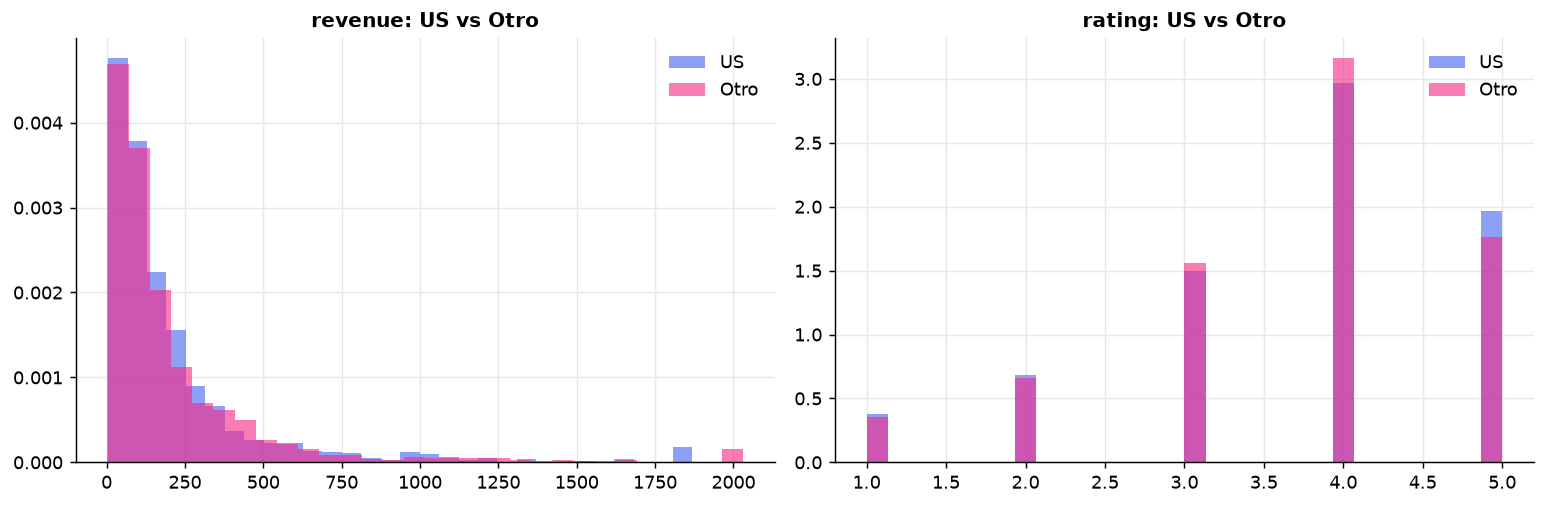

In [4]:
# Comparar usuarios de US vs. resto del mundo
df_us    = df[df['country'] == 'US']
df_other = df[df['country'] != 'US']

num_cols = ['price', 'quantity', 'revenue', 'rating']

print(f'US:    {len(df_us):,} órdenes | Otro: {len(df_other):,} órdenes')
print()

results = []
for col in num_cols:
    g1 = df_us[col].dropna()
    g2 = df_other[col].dropna()
    _, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    results.append({
        'feature':      col,
        'mean_US':      g1.mean().round(2),
        'mean_other':   g2.mean().round(2),
        'diff_%':       ((g1.mean() - g2.mean()) / g2.mean() * 100).round(1),
        'p_value':      round(p, 4),
        'significant':  '✓' if p < 0.05 else '',
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['revenue', 'rating']):
    g1 = df_us[col].dropna().clip(upper=df_us[col].quantile(0.99))
    g2 = df_other[col].dropna().clip(upper=df_other[col].quantile(0.99))
    ax.hist(g1, bins=30, alpha=0.6, density=True, color='#4361ee', label='US')
    ax.hist(g2, bins=30, alpha=0.6, density=True, color='#f72585', label='Otro')
    ax.set_title(f'{col}: US vs Otro')
    ax.legend()

plt.tight_layout()
plt.show()

## 4 — Checklist EDA para llevar a producción

In [5]:
# Generar checklist automático basado en los hallazgos
def eda_checklist(df: pd.DataFrame, findings: dict) -> None:
    print('EDA CHECKLIST')
    print('═' * 50)

    checks = [
        ('Shape verificado',                  True),
        ('Tipos de datos revisados',          True),
        ('Duplicados encontrados y tratados', findings.get('duplicates', 0) == 0),
        ('Sin missing values',                len(findings.get('missing', {})) == 0),
        ('Sin outliers severos (IQR)',        all(v < len(df)*0.02 for v in findings.get('outliers_iqr', {}).values())),
        ('Distribuciones documentadas',       True),
        ('Correlaciones revisadas',           'high_correlations' in findings),
        ('Estacionalidad revisada',           any(df.dtypes == 'datetime64[ns]')),
        ('Target analizado',                  True),
        ('Reporte generado',                  True),
    ]

    for label, ok in checks:
        icon = '✅' if ok else '⚠️ '
        print(f'  {icon} {label}')

    pending = [label for label, ok in checks if not ok]
    if pending:
        print(f'\nPendiente: {pending}')
    else:
        print('\n→ EDA completo. Listo para feature engineering / modelado.')

eda_checklist(df, findings)

EDA CHECKLIST
══════════════════════════════════════════════════
  ✅ Shape verificado
  ✅ Tipos de datos revisados
  ✅ Duplicados encontrados y tratados
  ⚠️  Sin missing values
  ⚠️  Sin outliers severos (IQR)
  ✅ Distribuciones documentadas
  ✅ Correlaciones revisadas
  ⚠️  Estacionalidad revisada
  ✅ Target analizado
  ✅ Reporte generado

Pendiente: ['Sin missing values', 'Sin outliers severos (IQR)', 'Estacionalidad revisada']


## Resumen del curso EDA

| Notebook | Tema | Herramientas |
|---|---|---|
| `01_data_profiling` | Estructura, tipos, missings, duplicados | `quick_profile()`, heatmap de missings |
| `02_distributions` | Distribuciones univariadas, skewness | Histograma, KDE, Q-Q plot, transformaciones |
| `03_relationships` | Correlaciones, relaciones bivariadas | Pearson, Spearman, Cramér's V, pair plot |
| `04_time_series_eda` | Tendencia, estacionalidad, descomposición | MA, heatmap hora×día, `seasonal_decompose` |
| `05_missing_data` | MCAR / MAR / MNAR, estrategias de imputación | `SimpleImputer`, `KNNImputer`, `IterativeImputer` |
| `06_outliers` | Detección univariada y multivariada | IQR, Z-Score, Isolation Forest, LOF |
| `07_eda_report` | Integración, automatización, reporte | `full_eda()`, ydata-profiling |

**Siguiente paso:** `sklearn_course/02_preprocessing.ipynb` — convertir los hallazgos del EDA en features para ML.